In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import math
import ast
import torch


def get_summary_df(dir_path: str) -> pd.DataFrame:
    """Returns the summary.csv file as a pandas dataframe.

    Args:
        dir_path (str): The path to the directory containing summary.csv.

    Returns:
        pd.DataFrame: The summary dataframe.
    """
    df = None
    while df is None:
        # If another process is writing to the file, it might raise an exception
        try:
            df = pd.read_csv(dir_path + os.sep + "summary.csv")
        except Exception as e:
            print(e)
    return df


def query(
    name: str,
    method: str | list[str] | tuple[str] | None = None,
    estimator: str | list[str] | tuple[str] | None = None,
    embedding_net: str | list[str] | tuple[str] | None = None,
    task: str | list[str] | tuple[str] | None = None,
    num_simulations: int | list[int] | tuple[int] | None = None,
    seed: int | list[int] | tuple[int] | None = None,
    metric: str | list[str] | tuple[str] | None = None,
    reduce_fn: str | None = "auto",
    **kwargs,
) -> pd.DataFrame:
    """Queries the summary.csv file.

    Args:
        name (str): The name of the summary file.
        method (str | list[str] | tuple[str], optional): The method(s) to query. Defaults to None.
        task (str | list[str] | tuple[str], optional): The task(s) to query. Defaults to None.
        num_simulations (int | list[int] | tuple[int], optional): The number of simulation(s) to query. Defaults to None.
        seed (int | list[int] | tuple[int], optional): The seed(s) to query. Defaults to None.
        metric (str | list[str] | tuple[str], optional): The metric(s) to query. Defaults to None.

    Returns:
        pd.DataFrame: The queried summary dataframe.
    """
    summary_df = get_summary_df(name)
    query = ""
    query += to_query_string("method", method)
    query += to_query_string("estimator", estimator)
    query += to_query_string("embedding_net", embedding_net)
    query += to_query_string("task", task)
    query += to_query_string("num_simulations", num_simulations)
    query += to_query_string("seed", seed)
    query += to_query_string("metric", metric)

    if query.endswith(" & "):
        query = query[:-3]
    if query == "":
        df = summary_df
    else:
        print(query)
        df = summary_df.query(query)

    if reduce_fn == "mean":

        def apply_fn(x):
            items = eval(x)
            return sum(items) / len(items)

        df.loc[:, "value"] = df["value"].apply(apply_fn)

    elif reduce_fn == "auto":
        # If metric == c2st/swd/std_dist -> mean
        # If metric == tarp/sbc -> p-value

        def apply_fn(value, metric):
            items = ast.literal_eval(value)
            if metric in ["c2st", "swd", "standardized_distance"]:
                return sum(items) / len(items)
            elif metric == "tarp":
                alpha, ecp = items
                ecp = torch.tensor(ecp)
                alpha = torch.tensor(alpha)
                # TODO: This is not a proper p-value
                # atc, ks_pval = check_tarp(ecp, alpha)
                num_sbc_samples = 1000
                test_stat_ks = torch.max(torch.abs(ecp - alpha))
                ks_pval = np.exp(-2 * test_stat_ks**2 * num_sbc_samples)
                return ks_pval
            elif metric == "sbc":
                ranks = torch.tensor(items)
                if ranks.ndim == 1:
                    ranks = ranks.unsqueeze(-1)
                mum_posterior_samples = ranks.max().item()
                pvals = check_uniformity_frequentist(
                    ranks, num_posterior_samples=mum_posterior_samples
                )
                return pvals
            else:
                return items

        # Apply the function in a single pass
        df["value"] = df.apply(
            lambda row: apply_fn(row["value"], row["metric"]), axis=1
        )

    return df


def to_query_string(name: str, var: any, end: str = " & ") -> str:
    """Translates a variable to string for query.

    Args:
        name (str): The query argument.
        var (any): The value to query.
        end (str, optional): The ending string for the query. Defaults to " & ".

    Returns:
        str: The query string.
    """
    if var is None:
        return ""
    elif (
        var is pd.NA
        or var is torch.nan
        or var is math.nan
        or str(var) == "nan"
        or var is np.nan
    ):
        return f"{name}!={name}"
    elif isinstance(var, list) or isinstance(var, tuple):
        query = "("
        for v in var:
            if query != "(":
                query += "|"
            if isinstance(v, str):
                query += f"{name}=='{v}'"
            else:
                query += f"{name}=={v}"
        query += ")"
    else:
        if isinstance(var, str):
            query = f"({name}=='{var}')"
        else:
            query = f"({name}=={var})"
    return query + end


DEFAULT_COLORS = {
    "nle": "#76b5c5",
    "snle": "#76b5c5",
    "nre": "#1e81b0",
    "snre": "#1e81b0",
    "npe": "#1f77b4",
    "snpe": "#1f77b4",
    "tsnpe": "#1f77b2",
    "tabpfn": "#f2a900",
    "ts_tabpfn": "#f2a900",
    "filtered_tabpfn": "#ff7f0e",
}

_custom_styles = ["pyloric"]
_mpl_styles = list(plt.style.available)
# path to pyloric style file
PATH = os.path.join("../../tabpfn_sbi/utils/")


def get_style(style, **kwargs):
    if style in _mpl_styles:
        return [style]
    elif style in _custom_styles:
        return [PATH + os.sep + style + ".mplstyle"]
    elif style == "science":
        return ["science"]
    elif style == "science_grid":
        return ["science", {"axes.grid": True}]
    elif style is None:
        return None
    else:
        return style


class use_style:
    def __init__(self, style, kwargs={}) -> None:
        super().__init__()
        self.style = get_style(style) + [kwargs]
        self.previous_style = {}

    def __enter__(self):
        self.previous_style = mpl.rcParams.copy()
        if self.style is not None:
            plt.style.use(self.style)

    def __exit__(self, *args, **kwargs):
        mpl.rcParams.update(self.previous_style)
        plt.show()  # Ensure the plot is displayed

In [3]:
from functools import partial

import matplotlib.pyplot as plt
import seaborn as sns

# from tabpfn_sbi.utils.plot_utils import DEFAULT_COLORS

# Note you need to have the results from the benchmarking in the results folder i.e. run by tabpfnbm!
name = "../../main_results/density_ratio"

fig_size = (1.5, 1)

gaussian_linear


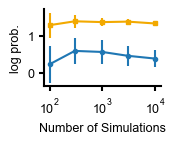

two_moons


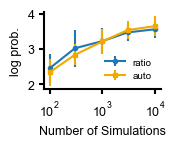

In [4]:
def plot_logprobs(name, task_name, legend=True):
    df = pd.read_csv(f"{name}/summary.csv")
    # filter by task_name
    df = df[df["task_name"] == task_name]
    # Sort by num_simulations
    df = df.sort_values(by="num_simulations")

    # Get unique num_simulations values
    num_simulations = df["num_simulations"].unique()

    # Calculate mean and std for each num_simulations value
    ratio_means = []
    ratio_stds = []
    auto_means = []
    auto_stds = []

    for ns in num_simulations:
        # Filter data for current num_simulations
        ns_data = df[df["num_simulations"] == ns]

        # Calculate mean and std for log_probs_ratio_mean
        ratio_means.append(ns_data["log_probs_ratio_mean"].mean())
        ratio_stds.append(ns_data["log_probs_ratio_mean"].std())

        # Calculate mean and std for log_probs_auto_mean
        auto_means.append(ns_data["log_probs_auto_mean"].mean())
        auto_stds.append(ns_data["log_probs_auto_mean"].std())

    # # Compute correlation between log_probs_ratio_mean and log_probs_auto_mean
    # correlation = np.corrcoef(ratio_means, auto_means)[0, 1]
    # print(f"Correlation between log_probs_ratio_mean and log_probs_auto_mean: {correlation:.4f}")

    with use_style("pyloric"):
        # Create the plot
        fig, ax = plt.subplots(figsize=fig_size)

        # Plot log_probs_ratio_mean with error bars
        ax.errorbar(
            num_simulations,
            ratio_means,
            yerr=ratio_stds,
            color=DEFAULT_COLORS["npe"],
            label="ratio",
            marker="o",
            linestyle="-",
            capsize=None,
        )

        # Plot log_probs_auto_mean with error bars
        ax.errorbar(
            num_simulations,
            auto_means,
            yerr=auto_stds,
            color=DEFAULT_COLORS["tabpfn"],
            label="auto",
            marker="s",
            linestyle="-",
            capsize=None,
        )

        ax.set_xlabel("Number of Simulations")
        ax.set_ylabel("log prob.")
        if legend:
            # ax.legend()
            # make legend smaller
            ax.legend(fontsize=7, loc="lower right")
        ax.set_xscale(
            "log"
        )  # Use log scale for x-axis since num_simulations grows exponentially
        ax.minorticks_off()

        # Save the figure
        plt.show()
        fig.savefig(f"logprob_{task_name}.svg", bbox_inches="tight", transparent=True)
        plt.close(fig)


for task_name in ["gaussian_linear", "two_moons"]:
    print(task_name)
    plot_logprobs(name, task_name, legend=True if task_name == "two_moons" else False)

gaussian_linear


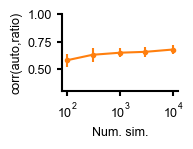

two_moons


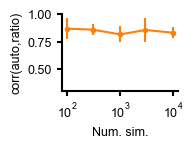

In [4]:
def plot_corr(name, task_name):
    df = pd.read_csv(f"{name}/summary.csv")
    # filter by task_name
    df = df[df["task_name"] == task_name]
    # Sort by num_simulations
    df = df.sort_values(by="num_simulations")

    # Get unique num_simulations values
    num_simulations = df["num_simulations"].unique()

    # Calculate mean and std for each num_simulations value
    corr_means = []
    corr_stds = []

    for ns in num_simulations:
        # Filter data for current num_simulations
        ns_data = df[df["num_simulations"] == ns]

        # Calculate mean and std for log_probs_ratio_mean
        corr_means.append(ns_data["exp_corr"].mean())
        corr_stds.append(ns_data["exp_corr"].std())

    with use_style("pyloric"):
        # Create the plot
        fig, ax = plt.subplots(figsize=fig_size)

        # Plot log_probs_ratio_mean with error bars
        ax.errorbar(
            num_simulations,
            corr_means,
            yerr=corr_stds,
            color=DEFAULT_COLORS["filtered_tabpfn"],
            label="ratio",
            marker="o",
            linestyle="-",
        )

        ax.set_xlabel("Num. sim.")
        ax.set_ylabel("corr(auto,ratio)")
        ax.set_xscale(
            "log"
        )  # Use log scale for x-axis since num_simulations grows exponentially
        ax.set_ylim(0.3, 1.0)
        ax.minorticks_off()

        # Save the figure
        plt.show()
        fig.savefig(
            f"density_corr_{task_name}.svg", bbox_inches="tight", transparent=True
        )
        plt.close(fig)


for task_name in ["gaussian_linear", "two_moons"]:
    print(task_name)
    plot_corr(name, task_name)

In [6]:
def get_median_max(name, task_name):
    df = pd.read_csv(f"{name}/summary.csv")
    # filter by task_name
    df = df[df["task_name"] == task_name]
    # Sort by num_simulations
    df = df.sort_values(by="num_simulations")

    num_sim = 10_000
    # Filter data for current num_simulations
    df = df[df["num_simulations"] == num_sim]

    # print median, max with seed, task_id
    corr_median = df["exp_corr"].median()
    corr_max = df["exp_corr"].max()

    print(np.array(df["exp_corr"]))
    # print corresponding task_id and seed for median and max
    print(
        f"MEDIAN: task_id {df[df['exp_corr'] == corr_median]['task_id'].unique().item()}, seed {df[df['exp_corr'] == corr_median]['seed'].unique().item()}; value {corr_median}"
    )
    print(
        f"MAX: task_id {df[df['exp_corr'] == corr_max]['task_id'].unique().item()}, seed {df[df['exp_corr'] == corr_max]['seed'].unique().item()}; value {corr_max}"
    )


for task_name in ["gaussian_linear", "two_moons"]:
    print(task_name)
    get_median_max(name, task_name)

gaussian_linear
[0.68163631 0.66626241 0.61989502 0.69629602 0.62444727 0.71160342
 0.71892608 0.7240277  0.62952275 0.71781369 0.67952878 0.70772805
 0.70608921 0.62661547 0.69024338]
MEDIAN: task_id 5, seed 4; value 0.6902433795931139
MAX: task_id 5, seed 1; value 0.7240276997925265
two_moons
[0.80048221 0.86852446 0.86986492 0.90085852 0.83049107 0.86341073
 0.87275916 0.82710904 0.75346334 0.86146309 0.71979346 0.85253065
 0.82623084 0.86497493 0.77951134]
MEDIAN: task_id 4, seed 1; value 0.8525306531139544
MAX: task_id 3, seed 0; value 0.900858523447594


gaussian_linear


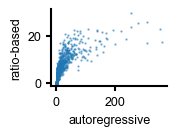

two_moons


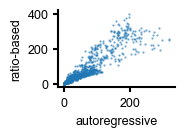

In [7]:
def plot_logprobs_scatter(name, task_name):
    with use_style("pyloric"):
        fig, ax = plt.subplots(1, 1, figsize=fig_size)  # , gridspec_kw={'wspace': 0.3})

        for i, value_type in enumerate(["max"]):  # "median",
            # torch load the files
            logprobs_auto = torch.load(
                f"{name}/logprobs_auto_{task_name}_{value_type}.pt"
            )
            logprobs_ratio = torch.load(
                f"{name}/logprobs_ratio_{task_name}_{value_type}.pt"
            )

            # exponentiate
            logprobs_auto = torch.exp(logprobs_auto)
            logprobs_ratio = torch.exp(logprobs_ratio)

            # limit to 1000 points
            logprobs_auto = logprobs_auto[:1000]
            logprobs_ratio = logprobs_ratio[:1000]

            # scatter plot
            ax.scatter(logprobs_auto, logprobs_ratio, alpha=0.5, s=0.5)

            # xlabel, ylabel
            ax.set_xlabel("autoregressive")
            ax.set_ylabel("ratio-based") if i == 0 else None
        plt.show()
        fig.savefig(
            f"density_scatter_{task_name}.svg", bbox_inches="tight", transparent=True
        )
        plt.close(fig)


for task_name in ["gaussian_linear", "two_moons"]:
    print(task_name)
    plot_logprobs_scatter(name, task_name)

gaussian_linear


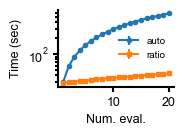

two_moons


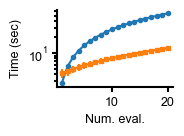

In [8]:
# Convert string representation of numpy arrays to actual arrays
import numpy as np
import ast
import re


def plot_time_cumsum(name, task_name, legend=True):
    df = pd.read_csv(f"{name}/summary_timing.csv")
    # filter by task_name
    df = df[df["task_name"] == task_name]

    # Function to convert string representation to numpy array
    def str_to_array(s):
        # Clean the string representation to ensure proper formatting
        # Add commas between numbers if missing
        if isinstance(s, str):
            # remove '\n\n'
            s = s.replace("\n", "")
            # Replace spaces between numbers with commas
            s = s.replace("    ", ",")
            s = s.replace("   ", ",")
            s = s.replace("  ", ",")
            s = s.replace(" ", ",")
            # Make sure it's a valid list format
            s = s.replace("[", "[").replace("]", "]")
            # replace initial [, with [
            s = s.replace("[,", "[")
            return np.array(ast.literal_eval(s))
        return np.array([])

    df["time_logprob_auto_cumsum"] = df["time_logprob_auto_cumsum"].apply(str_to_array)
    df["time_logprob_ratio_cumsum"] = df["time_logprob_ratio_cumsum"].apply(
        str_to_array
    )

    stacked_arrays = np.vstack(df["time_logprob_auto_cumsum"].values)
    mean_auto_cumsum = np.mean(stacked_arrays, axis=0)
    std_auto_cumsum = np.std(stacked_arrays, axis=0)

    stacked_arrays = np.vstack(df["time_logprob_ratio_cumsum"].values)
    mean_ratio_cumsum = np.mean(stacked_arrays, axis=0)
    std_ratio_cumsum = np.std(stacked_arrays, axis=0)

    num_evals = np.arange(1, len(mean_auto_cumsum) + 1)

    with use_style("pyloric"):
        fig, ax = plt.subplots(1, 1, figsize=fig_size, gridspec_kw={"wspace": 0.3})
        # ax.errorbar(num_simulations, corr_means, yerr=corr_stds,
        #     color=DEFAULT_COLORS['filtered_tabpfn'], label='ratio',
        #     marker='o', linestyle='-')

        ax.errorbar(
            num_evals,
            mean_auto_cumsum,
            yerr=std_auto_cumsum,
            color=DEFAULT_COLORS["npe"],
            label="auto",
            marker="o",
            linestyle="-",
        )
        ax.errorbar(
            num_evals,
            mean_ratio_cumsum,
            yerr=std_ratio_cumsum,
            color=DEFAULT_COLORS["filtered_tabpfn"],
            label="ratio",
            marker="s",
            linestyle="-",
        )

        # ax.errorbar(mean_auto_cumsum[:20], yerr=std_auto_cumsum[:20], label='auto')
        # ax.errorbar(mean_ratio_cumsum[:20], yerr=std_ratio_cumsum[:20], label='ratio')
        if legend:
            # ax.legend()
            # make legend smaller
            ax.legend(fontsize=7, loc="right")
        ax.set_xlabel("Num. eval.")
        ax.set_ylabel("Time (sec)")
        # ax.set_xscale('log')
        ax.set_yscale("log")
        # ax.minorticks_off()
        plt.show()
        fig.savefig(
            f"time_cumsum_{task_name}.svg", bbox_inches="tight", transparent=True
        )
        plt.close(fig)


for task_name in ["gaussian_linear", "two_moons"]:
    print(task_name)
    plot_time_cumsum(
        name, task_name, legend=True if task_name == "gaussian_linear" else False
    )

In [9]:
type(df["time_logprob_auto_cumsum"][0])

NameError: name 'df' is not defined